# Evolutionary Algorithms for Adaptive Business Rule Optimization  
## TransUnion Capstone – Fraud Detection

### Objective
The goal of this project is to evolve interpretable fraud detection rules using a Genetic Algorithm (GA).

Instead of using traditional machine learning models, we:
- Represent each solution as a simple AND-based rule
- Evolve rules over multiple generations
- Optimize fraud-sensitive metrics (Precision, Recall, F1)

This notebook demonstrates:
- Data preparation
- Feature screening
- Genetic rule evolution
- Validation and test evaluation



In [ ]:
# Install DEAP (only needed in Colab)
!pip -q install deap

import numpy as np
import pandas as pd
import random
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mutual_info_score
from deap import base, creator, tools
from google.colab import files

# Set reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.9 MB/s eta 0:00:00


## Step 1: Load and Inspect the Dataset

This dataset contains anonymized credit card transactions.

Each row represents one transaction.

Important columns:
- `Class` → Target variable (0 = legitimate, 1 = fraud)
- `Time` → Seconds since first transaction
- `Amount` → Transaction amount
- `V1–V28` → PCA-transformed anonymized features

Fraud is extremely rare (~0.17%), which makes this an imbalanced classification problem.


In [ ]:
# Upload creditcard.csv
uploaded = files.upload()

DATA_FILE = list(uploaded.keys())[0]
df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print("Fraud rate:", df["Class"].mean())
print(df.head())

Saving creditcard.csv to creditcard.csv
Dataset shape: (284807, 31)
Fraud rate: 0.001727485630620034
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533 

## Step 2: Basic Data Cleaning

We perform minimal cleaning:
- Remove duplicate transactions
- Ensure the fraud label (`Class`) is correctly formatted

This ensures the model is trained on clean and consistent data.

In [ ]:
# Remove duplicates (safe for this dataset)
df = df.drop_duplicates().reset_index(drop=True)

# Ensure Class column is integer
df["Class"] = df["Class"].astype(int)

print("After cleaning:", df.shape)

After cleaning: (283726, 31)


## Step 3: Train / Validation / Test Split

We divide the dataset into three parts:

- **Training Set (70%)** → Used to evolve candidate rules
- **Validation Set (15%)** → Used to evaluate rule fitness during evolution
- **Test Set (15%)** → Used for final performance reporting

We use *stratified splitting* so that fraud percentage remains consistent across splits.

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("Fraud rates:")
print("Train:", y_train.mean())
print("Val:", y_val.mean())
print("Test:", y_test.mean())

Fraud rates:
Train: 0.0016665995327479256
Val: 0.0016682722808336662
Test: 0.0016682722808336662


## Step 4: Fraud-Sensitive Evaluation Metrics

Because fraud is rare, accuracy is misleading.

Instead, we use:

- **Precision** → Of all flagged transactions, how many were actually fraud?
- **Recall** → Of all fraud cases, how many did we catch?
- **F1 Score** → Balanced combination of precision and recall.

We also compute confusion matrix values:
- TP (True Positives)
- FP (False Positives)
- FN (False Negatives)
- TN (True Negatives)

In [ ]:
def evaluate(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def confusion(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "TP": int(((y_pred==1)&(y_true==1)).sum()),
        "FP": int(((y_pred==1)&(y_true==0)).sum()),
        "FN": int(((y_pred==0)&(y_true==1)).sum()),
        "TN": int(((y_pred==0)&(y_true==0)).sum()),
    }

## Step 5: Feature Screening (Train-Only)

To improve search efficiency, we first identify the most informative features.

For each feature:
- We divide values into deciles (quantile bins)
- Measure how fraud rate changes across bins
- Compute Mutual Information (MI)

We select the top K features with the strongest fraud separation signal.

⚠ Important: This step uses ONLY the training set to avoid data leakage.

In [ ]:
def feature_screen(Xtr, ytr, max_bins=10):
    rows = []
    for col in Xtr.columns:
        uniq = Xtr[col].nunique()
        if uniq < 3:
            continue
        try:
            b = pd.qcut(Xtr[col], q=min(max_bins, uniq), duplicates="drop")
        except:
            continue

        tmp = pd.DataFrame({"bin": b, "Class": ytr}).dropna()
        if tmp["bin"].nunique() < 2:
            continue

        spread = tmp.groupby("bin", observed=True)["Class"].mean()
        spread = float(spread.max() - spread.min())

        mi = float(mutual_info_score(tmp["bin"].cat.codes, tmp["Class"]))

        rows.append({"feature": col, "mi": mi, "spread": spread})

    return pd.DataFrame(rows).sort_values(["mi","spread"], ascending=False)

rank_df = feature_screen(X_train, y_train)

TOP_K = 12
TOP_FEATURES = rank_df["feature"].head(TOP_K).tolist()

print("Selected features:")
print(TOP_FEATURES)

# Restrict dataset
X_train = X_train[TOP_FEATURES]
X_val   = X_val[TOP_FEATURES]
X_test  = X_test[TOP_FEATURES]

Selected features:
['V14', 'V4', 'V10', 'V12', 'V3', 'V11', 'V17', 'V16', 'V7', 'V2', 'V9', 'V27']


## Step 6: Rule Representation

Each individual in the Genetic Algorithm represents a single fraud detection rule.

Each rule:
- Contains 1 to 5 conditions
- Each condition looks like:
  - Feature ≤ threshold
  - OR Feature > threshold
- All conditions are combined using AND

Example rule:
V12 ≤ -1.96 AND V9 ≤ -0.64 AND V11 > 0.57

A transaction is flagged as fraud only if it satisfies ALL conditions.

In [ ]:
MIN_K = 1
MAX_K = 5
FEATURES = list(X_train.columns)

# Thresholds based on train quantiles
quantiles = np.linspace(0.05, 0.95, 19)
threshold_bank = {
    col: np.quantile(X_train[col].values, quantiles)
    for col in FEATURES
}

def random_condition():
    col = random.choice(FEATURES)
    direction = random.randint(0,1)
    thr = float(random.choice(threshold_bank[col]))
    return (col, direction, thr)

def random_rule():
    k = random.randint(MIN_K, MAX_K)
    return [random_condition() for _ in range(k)]

def apply_rule(rule, Xdf):
    mask = np.ones(len(Xdf), dtype=bool)
    for col, direction, thr in rule:
        if direction == 1:
            mask &= (Xdf[col] > thr)
        else:
            mask &= (Xdf[col] <= thr)
    return mask.astype(int)

def pretty(rule):
    parts=[]
    for col, direction, thr in rule:
        op=">" if direction==1 else "<="
        parts.append(f"{col} {op} {thr:.6f}")
    return " AND ".join(parts)

## Step 7: Fitness Function

The Genetic Algorithm needs a way to measure how good a rule is.

We define fitness as:

F1 Score on the Validation Set.

This ensures:
- The model balances fraud detection (recall)
- And false alarm control (precision)
- Without overfitting the training data

In [ ]:
def fitness(individual):
    y_pred = apply_rule(individual, X_val)
    return (f1_score(y_val, y_pred, zero_division=0),)

## Step 8: Genetic Algorithm Setup (DEAP)

We now configure DEAP:

- Define an Individual (a rule)
- Define a Population (collection of rules)
- Define Selection strategy (Tournament selection)
- Define Mutation and Crossover operators

This prepares the evolutionary search process.

In [ ]:
import copy

if "FitnessMax" not in creator.__dict__:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, random_rule)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", fitness)
toolbox.register("select", tools.selTournament, tournsize=3)

# FIX: clone using deepcopy
toolbox.register("clone", copy.deepcopy)

## Step 9: Evolution Operators

Mutation:
- Adjust a threshold
- Flip inequality direction
- Add or remove a condition

Crossover:
- Exchange conditions between two rules

These operators introduce variation and allow better rules to emerge over generations.

In [ ]:
def mutate(ind):
    op=random.choice(["thr","flip","replace","add","drop"])
    if op=="thr" and len(ind)>0:
        i=random.randrange(len(ind))
        col, direction,_=ind[i]
        ind[i]=(col,direction,float(random.choice(threshold_bank[col])))
    elif op=="flip" and len(ind)>0:
        i=random.randrange(len(ind))
        col,direction,thr=ind[i]
        ind[i]=(col,1-direction,thr)
    elif op=="replace" and len(ind)>0:
        ind[random.randrange(len(ind))]=random_condition()
    elif op=="add" and len(ind)<MAX_K:
        ind.append(random_condition())
    elif op=="drop" and len(ind)>MIN_K:
        ind.pop(random.randrange(len(ind)))
    return (ind,)

def crossover(ind1,ind2):
    if len(ind1)>0 and len(ind2)>0:
        i=random.randrange(len(ind1))
        j=random.randrange(len(ind2))
        ind1[i],ind2[j]=ind2[j],ind1[i]
    return ind1,ind2

toolbox.register("mate", crossover)
toolbox.register("mutate", mutate)

## Step 10: Running the Evolution

The GA process:

1. Generate an initial population of random rules
2. Evaluate each rule’s fitness
3. Select better-performing rules
4. Apply crossover and mutation
5. Repeat for multiple generations

Over time, rules improve through evolutionary selection.

In [ ]:
def run_ga(pop_size=80, generations=25):
    pop=toolbox.population(n=pop_size)

    for ind in pop:
        ind.fitness.values=toolbox.evaluate(ind)

    for g in range(generations):
        offspring=toolbox.select(pop,len(pop))
        offspring=list(map(toolbox.clone,offspring))

        for c1,c2 in zip(offspring[::2],offspring[1::2]):
            if random.random()<0.4:
                toolbox.mate(c1,c2)
                del c1.fitness.values,c2.fitness.values

        for ind in offspring:
            if random.random()<0.4:
                toolbox.mutate(ind)
                del ind.fitness.values

        invalid=[ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values=toolbox.evaluate(ind)

        pop[:]=offspring

        best=tools.selBest(pop,1)[0]
        if g%5==0:
            print("Gen",g,"Best F1:",best.fitness.values[0])

    return tools.selBest(pop,1)[0]

best_rule = run_ga()

print("\nBest Rule:")
print(pretty(best_rule))

Gen 0 Best F1: 0.518918918918919
Gen 5 Best F1: 0.6075949367088608
Gen 10 Best F1: 0.7384615384615385
Gen 15 Best F1: 0.7559055118110236
Gen 20 Best F1: 0.7559055118110236

Best Rule:
V12 <= -1.962711 AND V9 <= -0.644773 AND V11 > 0.578024 AND V10 <= -0.665089 AND V3 <= -0.887008


In [ ]:
val_pred  = apply_rule(best_rule, X_val)
test_pred = apply_rule(best_rule, X_test)

print("\nValidation metrics:", evaluate(y_val, val_pred))
print("Validation confusion:", confusion(y_val, val_pred))

print("\nTest metrics:", evaluate(y_test, test_pred))
print("Test confusion:", confusion(y_test, test_pred))


Validation metrics: {'precision': 0.8571428571428571, 'recall': 0.676056338028169, 'f1': 0.7559055118110236}
Validation confusion: {'TP': 48, 'FP': 8, 'FN': 23, 'TN': 42480}

Test metrics: {'precision': 0.7846153846153846, 'recall': 0.7183098591549296, 'f1': 0.75}
Test confusion: {'TP': 51, 'FP': 14, 'FN': 20, 'TN': 42474}


In [ ]:
results = {
    "top_features": TOP_FEATURES,
    "best_rule": pretty(best_rule),
    "val_metrics": evaluate(y_val,val_pred),
    "test_metrics": evaluate(y_test,test_pred)
}

with open("ga_results.json","w") as f:
    json.dump(results,f,indent=2)

files.download("ga_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

def rule_score(rule, Xdf):
    """
    Continuous score for a rule:
    score = fraction of conditions satisfied (0 to 1)

    If a rule has 5 conditions:
    - score = 1.0 means all 5 conditions satisfied
    - score = 0.6 means 3/5 satisfied
    """
    satisfied = np.zeros(len(Xdf), dtype=int)
    for col, direction, thr in rule:
        if direction == 1:  # >
            satisfied += (Xdf[col].values > thr).astype(int)
        else:               # <=
            satisfied += (Xdf[col].values <= thr).astype(int)
    return satisfied / len(rule)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_scores  = rule_score(best_rule, X_val)
test_scores = rule_score(best_rule, X_test)

print("VAL ROC-AUC:", roc_auc_score(y_val, val_scores))
print("VAL PR-AUC :", average_precision_score(y_val, val_scores))

print("TEST ROC-AUC:", roc_auc_score(y_test, test_scores))
print("TEST PR-AUC :", average_precision_score(y_test, test_scores))

VAL ROC-AUC: 0.9099102712679769
VAL PR-AUC : 0.5953946046386218
TEST ROC-AUC: 0.9236404114765793
TEST PR-AUC : 0.5768508076776369


In [ ]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_val, val_scores)

# thr has length = len(prec)-1, so ignore last precision/recall point
f1 = (2 * prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)

best_idx = np.argmax(f1)
best_thr = thr[best_idx]

print("Best threshold (max F1) on VAL:", best_thr)
print("Best VAL F1:", f1[best_idx], "Precision:", prec[best_idx], "Recall:", rec[best_idx])

# Apply threshold to get final predictions
val_pred_opt  = (val_scores  >= best_thr).astype(int)
test_pred_opt = (test_scores >= best_thr).astype(int)

print("\nVAL metrics (optimized threshold):", evaluate(y_val, val_pred_opt))
print("TEST metrics (optimized threshold):", evaluate(y_test, test_pred_opt))

Best threshold (max F1) on VAL: 1.0
Best VAL F1: 0.7559055118105305 Precision: 0.8571428571428571 Recall: 0.676056338028169

VAL metrics (optimized threshold): {'precision': 0.8571428571428571, 'recall': 0.676056338028169, 'f1': 0.7559055118110236}
TEST metrics (optimized threshold): {'precision': 0.7846153846153846, 'recall': 0.7183098591549296, 'f1': 0.75}


In [ ]:
min_precision = 0.10

prec, rec, thr = precision_recall_curve(y_val, val_scores)

prec_t = prec[:-1]
rec_t  = rec[:-1]
thr_t  = thr

ok = prec_t >= min_precision
if not np.any(ok):
    print("No threshold meets precision floor:", min_precision)
else:
    # Among thresholds meeting precision floor, pick the one with max recall
    idx = np.argmax(rec_t[ok])
    best_thr_pf = thr_t[ok][idx]

    print("Best threshold (precision floor) on VAL:", best_thr_pf)
    print("VAL Precision:", prec_t[ok][idx], "VAL Recall:", rec_t[ok][idx])

    val_pred_pf  = (val_scores  >= best_thr_pf).astype(int)
    test_pred_pf = (test_scores >= best_thr_pf).astype(int)

    print("\nVAL metrics (precision floor):", evaluate(y_val, val_pred_pf))
    print("TEST metrics (precision floor):", evaluate(y_test, test_pred_pf))

Best threshold (precision floor) on VAL: 0.8
VAL Precision: 0.19133574007220217 VAL Recall: 0.7464788732394366

VAL metrics (precision floor): {'precision': 0.19133574007220217, 'recall': 0.7464788732394366, 'f1': 0.3045977011494253}
TEST metrics (precision floor): {'precision': 0.2, 'recall': 0.7746478873239436, 'f1': 0.3179190751445087}


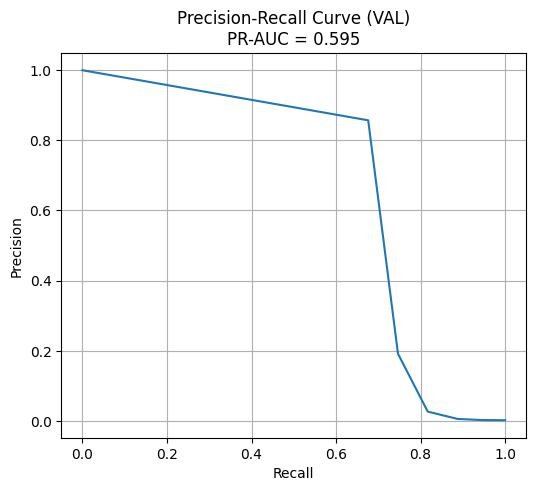

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute PR curve
prec, rec, _ = precision_recall_curve(y_val, val_scores)
pr_auc = average_precision_score(y_val, val_scores)

plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (VAL)\nPR-AUC = {pr_auc:.3f}")
plt.grid(True)
plt.show()

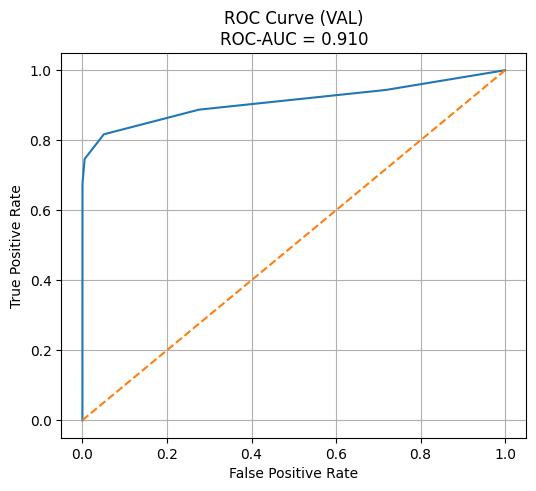

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_val, val_scores)
roc_auc = roc_auc_score(y_val, val_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (VAL)\nROC-AUC = {roc_auc:.3f}")
plt.grid(True)
plt.show()

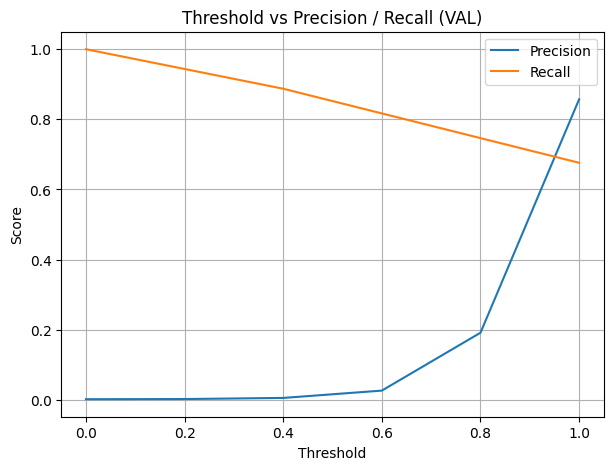

In [ ]:
prec, rec, thr = precision_recall_curve(y_val, val_scores)

# Remove last value to align with thresholds
prec = prec[:-1]
rec = rec[:-1]

plt.figure(figsize=(7,5))
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall (VAL)")
plt.legend()
plt.grid(True)
plt.show()

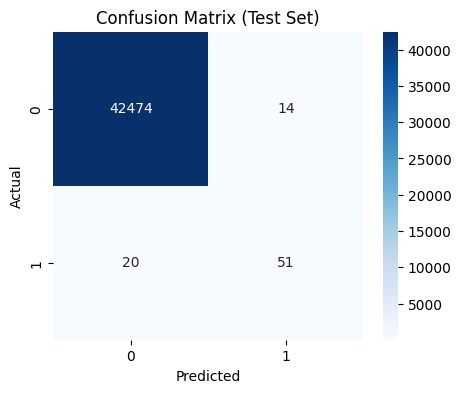

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()